In [ ]:
!pip install -q xlrd openpyxl xgboost scikit-learn seaborn joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    TimeSeriesSplit
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor

import joblib

# Style des graphiques
sns.set_theme(style="whitegrid")

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_temps_rade_port_alger_enrichi_5_15j.xls to dataset_temps_rade_port_alger_enrichi_5_15j.xls


In [ ]:
# Récupérer automatiquement le nom du fichier uploadé

file_name = list(uploaded.keys())[0]

print("Fichier chargé :", file_name)

Fichier chargé : dataset_temps_rade_port_alger_enrichi_5_15j.xls


In [ ]:
# Lire le fichier Excel

df = pd.read_excel(file_name)

print("Dataset chargé avec succès.")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Dataset chargé avec succès.
Nombre de lignes : 645
Nombre de colonnes : 19


In [ ]:
# ANALYSE GÉNÉRALE DU DATASET


print("Dimensions du dataset :", df.shape)

print("\n--- Colonnes ---")
print(df.columns.tolist())

print("\n--- Premières lignes ---")
display(df.head())

print("\n--- Informations générales ---")
df.info()

Dimensions du dataset : (645, 19)

--- Colonnes ---
['Navire', 'IMO', 'Type', 'Port', 'Date_arrivee_rade', 'Date_depart_rade', 'Duree_en_rade', 'Duree_en_rade_heures', 'Raison', 'Jauge_brute_GT', 'Longueur_LOA_m', 'Tirant_eau_m', 'Navires_en_attente_rade', 'Indice_congestion_port', 'Conditions_meteo', 'Poste_a_quai_assigne', 'Jour_semaine', 'Mois', 'Annee']

--- Premières lignes ---


,Navire,IMO,Type,Port,Date_arrivee_rade,Date_depart_rade,Duree_en_rade,Duree_en_rade_heures,Raison,Jauge_brute_GT,Longueur_LOA_m,Tirant_eau_m,Navires_en_attente_rade,Indice_congestion_port,Conditions_meteo,Poste_a_quai_assigne,Jour_semaine,Mois,Annee
0,MSC/CMA Star 8,IMO9996519,Porte-conteneurs,Port d'Alger,2022-01-01 02:30,2022-01-02 23:51,45h22,45.36,Attente poste à quai,67565,286.8,16.4,10,0.82,Beau temps,Q4,Samedi,1,2022
1,MT Aurès 7,IMO9517033,Pétrolier,Port d'Alger,2022-01-03 01:45,2022-01-05 05:17,51h32,51.54,Attente pilote,37299,194.4,12.7,7,0.64,Houle,Q9,Lundi,1,2022
2,MT Ocean 8,IMO9819065,Pétrolier,Port d'Alger,2022-01-08 12:05,2022-01-22 06:41,330h36,330.60,Encombrement quai sévère,17191,202.4,14.0,22,0.82,Mer agitée,Q3,Samedi,1,2022
3,MV Voyager 1,IMO9588508,Vraquier,Port d'Alger,2022-01-11 02:00,2022-01-13 09:35,55h36,55.60,Encombrement quai,27798,219.0,12.1,4,0.16,Beau temps,Q2,Mardi,1,2022
4,MV Levant 1,IMO9240174,Céréalier,Port d'Alger,2022-01-12 03:45,2022-01-14 02:22,46h37,46.62,Attente poste à quai,56601,216.1,14.6,2,0.11,Beau temps,Q9,Mercredi,1,2022



--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Navire                   645 non-null    object 
 1   IMO                      645 non-null    object 
 2   Type                     645 non-null    object 
 3   Port                     645 non-null    object 
 4   Date_arrivee_rade        645 non-null    object 
 5   Date_depart_rade         645 non-null    object 
 6   Duree_en_rade            645 non-null    object 
 7   Duree_en_rade_heures     645 non-null    float64
 8   Raison                   645 non-null    object 
 9   Jauge_brute_GT           645 non-null    int64  
 10  Longueur_LOA_m           645 non-null    float64
 11  Tirant_eau_m             645 non-null    float64
 12  Navires_en_attente_rade  645 non-null    int64  
 13  Indice_congestion_port   645 non-null    float64

In [ ]:
# VALEURS MANQUANTES
missing = pd.DataFrame({
    "Colonne": df.columns,
    "Valeurs_manquantes": df.isnull().sum(),
    "Pourcentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Valeurs_manquantes",
    ascending=False
)

display(missing)

,Colonne,Valeurs_manquantes,Pourcentage
Navire,Navire,0,0.0
IMO,IMO,0,0.0
Type,Type,0,0.0
Port,Port,0,0.0
Date_arrivee_rade,Date_arrivee_rade,0,0.0
Date_depart_rade,Date_depart_rade,0,0.0
Duree_en_rade,Duree_en_rade,0,0.0
Duree_en_rade_heures,Duree_en_rade_heures,0,0.0
Raison,Raison,0,0.0
Jauge_brute_GT,Jauge_brute_GT,0,0.0


In [ ]:
# DOUBLONS

duplicates = df.duplicated().sum()

print("Nombre de doublons :", duplicates)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Doublons supprimés.")

print("Nouvelle dimension :", df.shape)

Nombre de doublons : 0
Nouvelle dimension : (645, 19)


In [ ]:
# TYPES DES VARIABLES

print(df.dtypes)

Navire                      object
IMO                         object
Type                        object
Port                        object
Date_arrivee_rade           object
Date_depart_rade            object
Duree_en_rade               object
Duree_en_rade_heures       float64
Raison                      object
Jauge_brute_GT               int64
Longueur_LOA_m             float64
Tirant_eau_m               float64
Navires_en_attente_rade      int64
Indice_congestion_port     float64
Conditions_meteo            object
Poste_a_quai_assigne        object
Jour_semaine                object
Mois                         int64
Annee                        int64
dtype: object


In [ ]:
# CONVERSION DES DATES

df["Date_arrivee_rade"] = pd.to_datetime(
    df["Date_arrivee_rade"],
    errors="coerce"
)

df["Date_depart_rade"] = pd.to_datetime(
    df["Date_depart_rade"],
    errors="coerce"
)

print(df[[
    "Date_arrivee_rade",
    "Date_depart_rade"
]].dtypes)

Date_arrivee_rade    datetime64[ns]
Date_depart_rade     datetime64[ns]
dtype: object


In [ ]:
# VÉRIFICATION DE LA VARIABLE CIBLE

# Calcul indépendant de la durée à partir des dates

df["Duree_calculee_heures"] = (
    df["Date_depart_rade"] -
    df["Date_arrivee_rade"]
).dt.total_seconds() / 3600

# Différence entre la durée fournie et la durée calculée

df["Difference_duree"] = (
    df["Duree_en_rade_heures"] -
    df["Duree_calculee_heures"]
)

print("Erreur moyenne :",
      df["Difference_duree"].mean())

print("Erreur maximale absolue :",
      df["Difference_duree"].abs().max())

Erreur moyenne : 0.00636692506459933
Erreur maximale absolue : 0.020000000000003126


In [ ]:
# Afficher quelques exemples

display(
    df[[
        "Date_arrivee_rade",
        "Date_depart_rade",
        "Duree_en_rade_heures",
        "Duree_calculee_heures",
        "Difference_duree"
    ]].head(10)
)

,Date_arrivee_rade,Date_depart_rade,Duree_en_rade_heures,Duree_calculee_heures,Difference_duree
0,2022-01-01 02:30:00,2022-01-02 23:51:00,45.36,45.350000,0.010000
1,2022-01-03 01:45:00,2022-01-05 05:17:00,51.54,51.533333,0.006667
2,2022-01-08 12:05:00,2022-01-22 06:41:00,330.60,330.600000,0.000000
3,2022-01-11 02:00:00,2022-01-13 09:35:00,55.60,55.583333,0.016667
4,2022-01-12 03:45:00,2022-01-14 02:22:00,46.62,46.616667,0.003333
5,2022-01-20 14:30:00,2022-01-22 06:17:00,39.79,39.783333,0.006667
6,2022-01-20 15:15:00,2022-01-23 19:12:00,75.96,75.950000,0.010000
7,2022-01-21 16:20:00,2022-01-23 12:14:00,43.91,43.900000,0.010000
8,2022-02-08 14:40:00,2022-02-10 12:04:00,45.41,45.400000,0.010000
9,2022-02-09 12:40:00,2022-02-10 20:10:00,31.50,31.500000,0.000000


In [ ]:
# STATISTIQUES DE LA VARIABLE CIBLE

print(df["Duree_en_rade_heures"].describe())

count    645.000000
mean     106.735307
std       95.342264
min       12.930000
25%       45.220000
50%       58.370000
75%      152.650000
max      359.000000
Name: Duree_en_rade_heures, dtype: float64


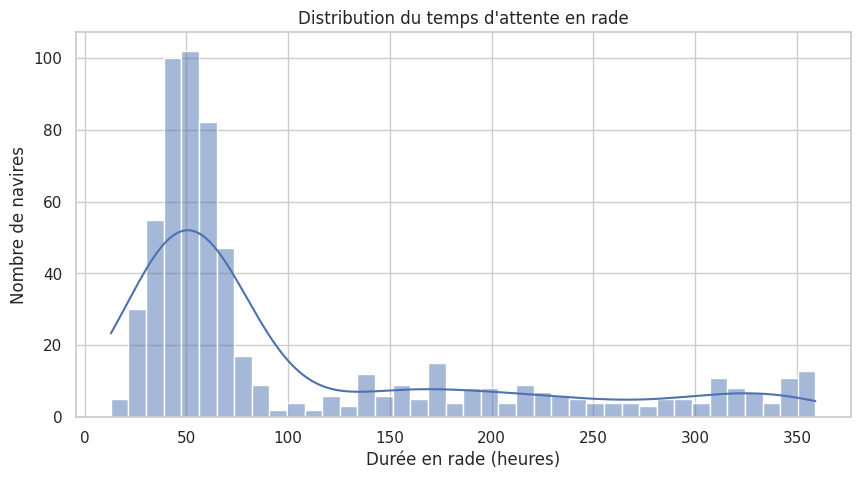

In [ ]:
# Distribution du temps d'attente

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Duree_en_rade_heures"],
    bins=40,
    kde=True
)

plt.title("Distribution du temps d'attente en rade")
plt.xlabel("Durée en rade (heures)")
plt.ylabel("Nombre de navires")

plt.show()

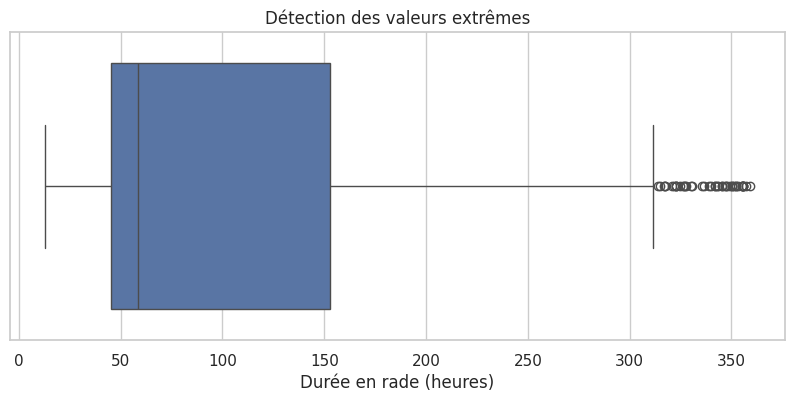

In [ ]:
# Boxplot

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["Duree_en_rade_heures"]
)

plt.title("Détection des valeurs extrêmes")
plt.xlabel("Durée en rade (heures)")

plt.show()

In [ ]:
# ANALYSE DES VARIABLES CATÉGORIELLES

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:

    print("\n================================")
    print(col)
    print("Nombre de catégories :", df[col].nunique())

    display(
        df[col].value_counts().head(15)
    )


Navire
Nombre de catégories : 455


,count
Navire,
MSC/CMA Sahel 9,11
MV Voyager 1,11
MT Hoggar 5,11
MV Pioneer 2,10
MV Emeraude 7,10
RoRo Baltic 3,8
MV Hoggar 6,8
MV Zaccar 1,8
MSC/CMA Pioneer 4,8



IMO
Nombre de catégories : 510


,count
IMO,
IMO9588508,11
IMO9735911,11
IMO9230283,11
IMO9619176,10
IMO9082627,9
IMO9171339,8
IMO9693384,8
IMO9633052,8
IMO9638720,8



Type
Nombre de catégories : 7


...

,count
Conditions_meteo,
Beau temps,317
Vent fort,107
Mer agitée,100
Houle,88
Brouillard,33



Poste_a_quai_assigne
Nombre de catégories : 12


,count
Poste_a_quai_assigne,
Q11,73
Q9,69
Q8,65
Q4,62
Q7,54
Q6,54
Q2,48
Q3,47
Q12,45



Jour_semaine
Nombre de catégories : 7


,count
Jour_semaine,
Mercredi,104
Vendredi,102
Jeudi,97
Lundi,92
Dimanche,92
Samedi,82
Mardi,76


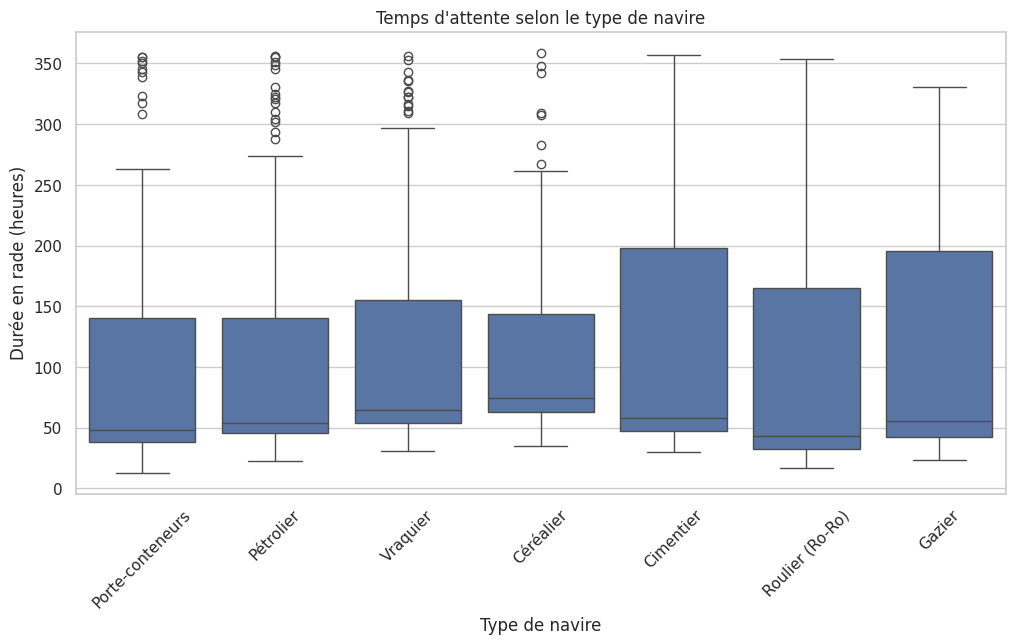

In [ ]:
# TEMPS D'ATTENTE PAR TYPE DE NAVIRE

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Type",
    y="Duree_en_rade_heures"
)

plt.xticks(rotation=45)

plt.title("Temps d'attente selon le type de navire")
plt.xlabel("Type de navire")
plt.ylabel("Durée en rade (heures)")

plt.show()

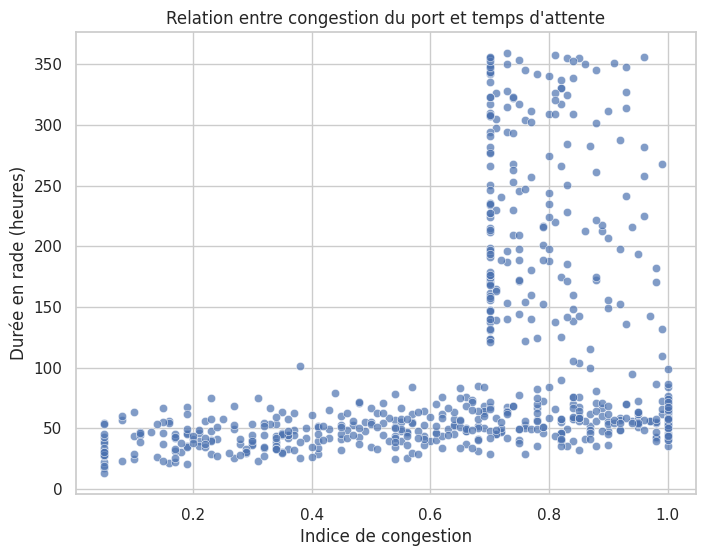

In [ ]:
# RELATION CONGESTION / TEMPS D'ATTENTE

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Indice_congestion_port",
    y="Duree_en_rade_heures",
    alpha=0.7
)

plt.title(
    "Relation entre congestion du port et temps d'attente"
)

plt.xlabel("Indice de congestion")
plt.ylabel("Durée en rade (heures)")

plt.show()

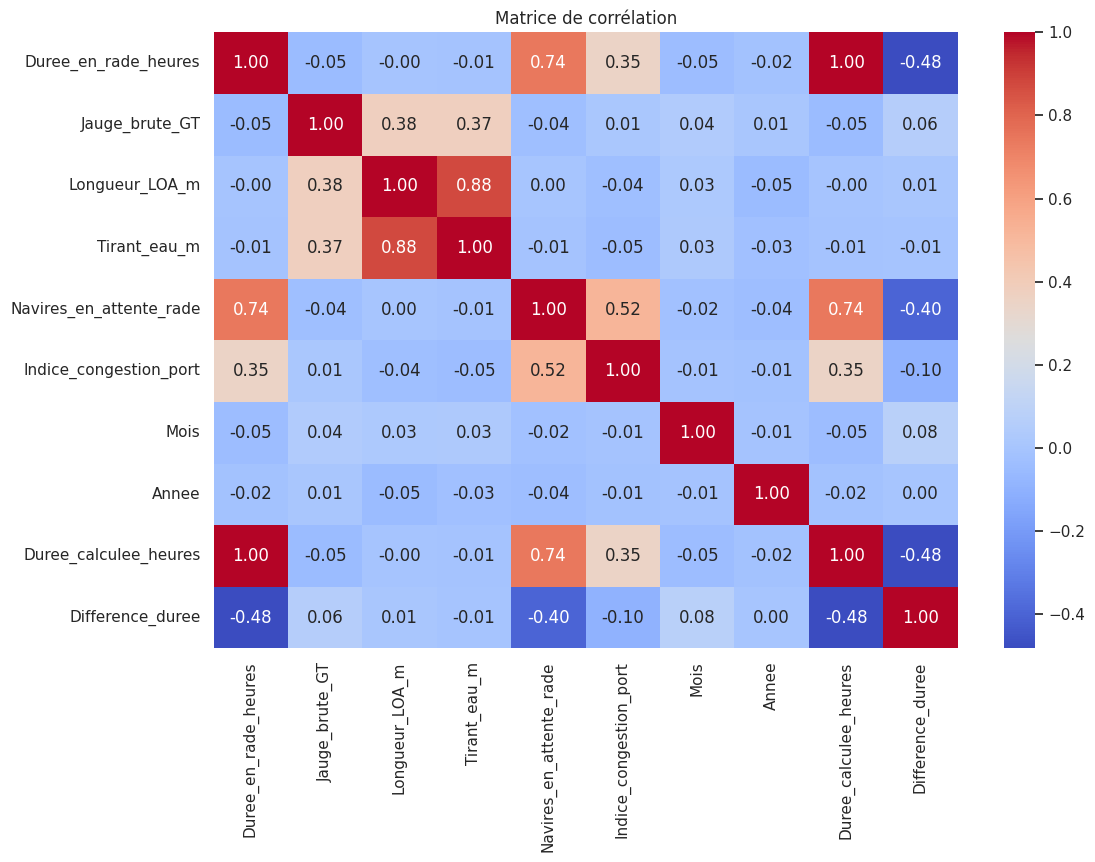

In [ ]:
# MATRICE DE CORRÉLATION

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

In [ ]:
# FEATURE ENGINEERING

df["heure_arrivee"] = df["Date_arrivee_rade"].dt.hour

df["minute_arrivee"] = (
    df["Date_arrivee_rade"].dt.minute
)

df["jour"] = df["Date_arrivee_rade"].dt.day

df["mois_arrivee"] = (
    df["Date_arrivee_rade"].dt.month
)

df["annee_arrivee"] = (
    df["Date_arrivee_rade"].dt.year
)

df["jour_semaine_num"] = (
    df["Date_arrivee_rade"].dt.dayofweek
)

df["weekend"] = (
    df["jour_semaine_num"] >= 5
).astype(int)

df["trimestre"] = (
    df["Date_arrivee_rade"].dt.quarter
)

In [ ]:
# VARIABLES CYCLIQUES

# Une heure 23h est proche de 0h.
# Une simple variable numérique ne représente pas bien cela.
# On utilise donc sin/cos.

df["heure_sin"] = np.sin(
    2 * np.pi * df["heure_arrivee"] / 24
)

df["heure_cos"] = np.cos(
    2 * np.pi * df["heure_arrivee"] / 24
)

df["mois_sin"] = np.sin(
    2 * np.pi * df["mois_arrivee"] / 12
)

df["mois_cos"] = np.cos(
    2 * np.pi * df["mois_arrivee"] / 12
)

In [ ]:
# CONSTRUCTION DU DATASET ML

target = "Duree_en_rade_heures"

features = [
    "Type",
    "Jauge_brute_GT",
    "Longueur_LOA_m",
    "Tirant_eau_m",
    "Navires_en_attente_rade",
    "Indice_congestion_port",
    "Conditions_meteo",

    # Variables temporelles
    "heure_arrivee",
    "jour",
    "mois_arrivee",
    "annee_arrivee",
    "jour_semaine_num",
    "weekend",
    "trimestre",

    # Variables cycliques
    "heure_sin",
    "heure_cos",
    "mois_sin",
    "mois_cos"
]

X = df[features].copy()

y = df[target].copy()

print("X :", X.shape)
print("y :", y.shape)

display(X.head())

X : (645, 18)
y : (645,)


,Type,Jauge_brute_GT,Longueur_LOA_m,Tirant_eau_m,Navires_en_attente_rade,Indice_congestion_port,Conditions_meteo,heure_arrivee,jour,mois_arrivee,annee_arrivee,jour_semaine_num,weekend,trimestre,heure_sin,heure_cos,mois_sin,mois_cos
0,Porte-conteneurs,67565,286.8,16.4,10,0.82,Beau temps,2,1,1,2022,5,1,1,5.000000e-01,0.866025,0.5,0.866025
1,Pétrolier,37299,194.4,12.7,7,0.64,Houle,1,3,1,2022,0,0,1,2.588190e-01,0.965926,0.5,0.866025
2,Pétrolier,17191,202.4,14.0,22,0.82,Mer agitée,12,8,1,2022,5,1,1,1.224647e-16,-1.000000,0.5,0.866025
3,Vraquier,27798,219.0,12.1,4,0.16,Beau temps,2,11,1,2022,1,0,1,5.000000e-01,0.866025,0.5,0.866025
4,Céréalier,56601,216.1,14.6,2,0.11,Beau temps,3,12,1,2022,2,0,1,7.071068e-01,0.707107,0.5,0.866025


In [ ]:
# TRI CHRONOLOGIQUE

model_df = df[
    features + [target, "Date_arrivee_rade"]
].copy()

model_df = model_df.sort_values(
    "Date_arrivee_rade"
).reset_index(drop=True)

X = model_df[features]

y = model_df[target]

In [ ]:
# TRAIN / VALIDATION / TEST

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (451, 18)
Validation : (97, 18)
Test : (97, 18)


In [ ]:
# PRÉPROCESSING

categorical_features = [
    "Type",
    "Conditions_meteo"
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## MODEL 1 - RANDOM FOREST

In [ ]:
# RANDOM FOREST

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest entraîné.")

Random Forest entraîné.


In [ ]:
# FONCTION D'ÉVALUATION

def evaluate_model(model, X_data, y_data, name):

    predictions = model.predict(X_data)

    mae = mean_absolute_error(
        y_data,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_data,
            predictions
        )
    )

    r2 = r2_score(
        y_data,
        predictions
    )

    mape = mean_absolute_percentage_error(
        y_data,
        predictions
    ) * 100

    print("\n==============================")
    print(name)
    print("==============================")

    print(f"MAE  : {mae:.2f} heures")
    print(f"RMSE : {rmse:.2f} heures")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "Modèle": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [ ]:
# Evaluation random forest

results = []

results.append(
    evaluate_model(
        rf_model,
        X_val,
        y_val,
        "Random Forest"
    )
)


Random Forest
MAE  : 45.90 heures
RMSE : 62.27 heures
R²   : 0.5342
MAPE : 56.75%


## MODEL 2 - EXTRA TREES

In [ ]:
# EXTRA TREES
# Extra Trees est particulièrement intéressant sur un petit dataset tabulaire.

et_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

et_model.fit(
    X_train,
    y_train
)

results.append(
    evaluate_model(
        et_model,
        X_val,
        y_val,
        "Extra Trees"
    )
)


Extra Trees
MAE  : 41.05 heures
RMSE : 61.29 heures
R²   : 0.5488
MAPE : 45.00%


## MODEL 3 - GRADIENT BOOSTING

In [ ]:
# GRADIENT BOOSTING

gb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,
                min_samples_leaf=3,
                loss="huber",
                random_state=42
            )
        )
    ]
)

gb_model.fit(
    X_train,
    y_train
)

results.append(
    evaluate_model(
        gb_model,
        X_val,
        y_val,
        "Gradient Boosting"
    )
)


Gradient Boosting
MAE  : 38.76 heures
RMSE : 61.72 heures
R²   : 0.5424
MAPE : 41.36%


## MODEL 4 - XGBOOST

In [ ]:
# XGBOOST

xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

results.append(
    evaluate_model(
        xgb_model,
        X_val,
        y_val,
        "XGBoost"
    )
)


XGBoost
MAE  : 44.23 heures
RMSE : 64.17 heures
R²   : 0.5055
MAPE : 54.53%


## COMPARAISON DES MODELS

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE"
)

display(results_df)

,Modèle,MAE,RMSE,R2,MAPE
2,Gradient Boosting,38.760475,61.723423,0.542387,41.358587
1,Extra Trees,41.047425,61.287529,0.548828,45.000405
3,XGBoost,44.231181,64.165510,0.505460,54.528808
0,Random Forest,45.899227,62.272270,0.534213,56.751931


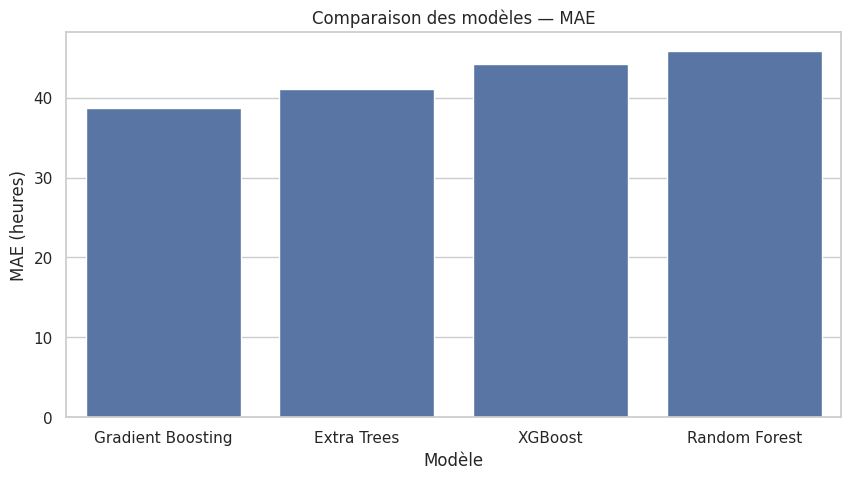

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Modèle",
    y="MAE"
)

plt.title("Comparaison des modèles — MAE")
plt.ylabel("MAE (heures)")

plt.show()

In [ ]:
# OPTIMISATION XGBOOST

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
param_grid = {
    "model__n_estimators": [
        200,
        400,
        600,
        800
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "model__min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__reg_alpha": [
        0,
        0.01,
        0.1,
        0.5
    ],

    "model__reg_lambda": [
        1,
        2,
        5,
        10
    ]
}

In [ ]:
# RANDOMIZED SEARCH

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,

    n_iter=40,

    scoring="neg_mean_absolute_error",

    cv=TimeSeriesSplit(n_splits=4),

    verbose=1,

    random_state=42,

    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

print("Recherche terminée.")

Fitting 4 folds for each of 40 candidates, totalling 160 fits
Recherche terminée.


In [ ]:
print("Meilleurs paramètres :")

print(search.best_params_)

print(
    "\nMeilleur MAE CV :",
    -search.best_score_
)

Meilleurs paramètres :
{'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__reg_alpha': 0.01, 'model__n_estimators': 600, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

Meilleur MAE CV : 34.132212435121886


In [ ]:
best_xgb = search.best_estimator_

results.append(
    evaluate_model(
        best_xgb,
        X_val,
        y_val,
        "XGBoost optimisé"
    )
)


XGBoost optimisé
MAE  : 40.36 heures
RMSE : 62.33 heures
R²   : 0.5334
MAPE : 44.91%


In [ ]:
# SÉLECTION DU MEILLIEUR MODELE

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

display(results_df)

best_model_name = results_df.iloc[0]["Modèle"]

print(
    "Meilleur modèle sur validation :",
    best_model_name
)

,Modèle,MAE,RMSE,R2,MAPE
0,Gradient Boosting,38.760475,61.723423,0.542387,41.358587
1,XGBoost optimisé,40.357326,62.328861,0.533366,44.911022
2,Extra Trees,41.047425,61.287529,0.548828,45.000405
3,XGBoost,44.231181,64.165510,0.505460,54.528808
4,Random Forest,45.899227,62.272270,0.534213,56.751931


Meilleur modèle sur validation : Gradient Boosting


In [ ]:
models = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "XGBoost optimisé": best_xgb
}

best_model = models[best_model_name]

In [ ]:
# ÉVALUATION FINALE SUR LE TEST

test_predictions = best_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

test_mape = (
    mean_absolute_percentage_error(
        y_test,
        test_predictions
    ) * 100
)

print("================================")
print("PERFORMANCE FINALE")
print("================================")

print(f"MAE  : {test_mae:.2f} heures")
print(f"RMSE : {test_rmse:.2f} heures")
print(f"R²   : {test_r2:.4f}")
print(f"MAPE : {test_mape:.2f}%")

PERFORMANCE FINALE
MAE  : 34.40 heures
RMSE : 54.30 heures
R²   : 0.6748
MAPE : 33.23%


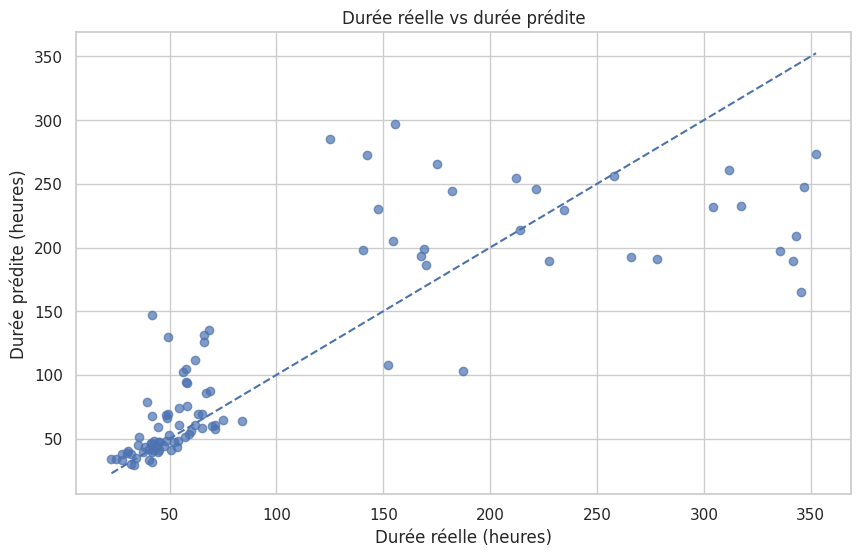

In [ ]:
# RÉEL VS PRÉDIT

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.7
)

# Ligne parfaite
min_value = min(
    y_test.min(),
    test_predictions.min()
)

max_value = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Durée réelle (heures)")
plt.ylabel("Durée prédite (heures)")

plt.title(
    "Durée réelle vs durée prédite"
)

plt.show()

In [ ]:
# ANALYSE DES ERREURS

error_df = pd.DataFrame({
    "Reel": y_test.values,
    "Predit": test_predictions
})

error_df["Erreur"] = (
    error_df["Predit"] -
    error_df["Reel"]
)

error_df["Erreur_absolue"] = (
    error_df["Erreur"].abs()
)

display(
    error_df.sort_values(
        "Erreur_absolue",
        ascending=False
    ).head(20)
)

,Reel,Predit,Erreur,Erreur_absolue
16,345.280000,165.005570,-180.274430,180.274430
70,125.283333,285.285166,160.001832,160.001832
49,341.883333,189.174379,-152.708954,152.708954
35,155.416667,296.750001,141.333334,141.333334
69,335.616667,197.358413,-138.258253,138.258253
89,343.250000,208.948898,-134.301102,134.301102
40,142.310000,272.808825,130.498825,130.498825
36,41.800000,147.281687,105.481687,105.481687
82,346.766667,247.868079,-98.898588,98.898588
33,174.900000,265.721204,90.821204,90.821204


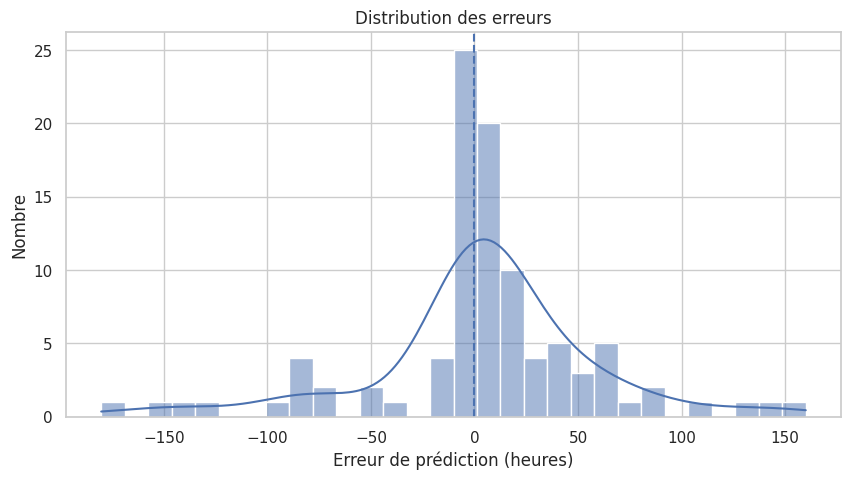

In [ ]:
# Distribution des erreurs

plt.figure(figsize=(10, 5))

sns.histplot(
    error_df["Erreur"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution des erreurs")

plt.xlabel("Erreur de prédiction (heures)")
plt.ylabel("Nombre")

plt.show()

In [ ]:
importances = best_model.named_steps["model"].feature_importances_
prep_step = best_model.named_steps["preprocessor"]
feature_names = prep_step.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(
    importance_df.head(20)
)

,Feature,Importance
3,num__Navires_en_attente_rade,0.738949
4,num__Indice_congestion_port,0.154087
1,num__Longueur_LOA_m,0.030754
2,num__Tirant_eau_m,0.010610
0,num__Jauge_brute_GT,0.009831
23,cat__Conditions_meteo_Beau temps,0.008855
6,num__jour,0.005902
17,cat__Type_Céréalier,0.005421
13,num__heure_cos,0.005184
14,num__mois_sin,0.004340


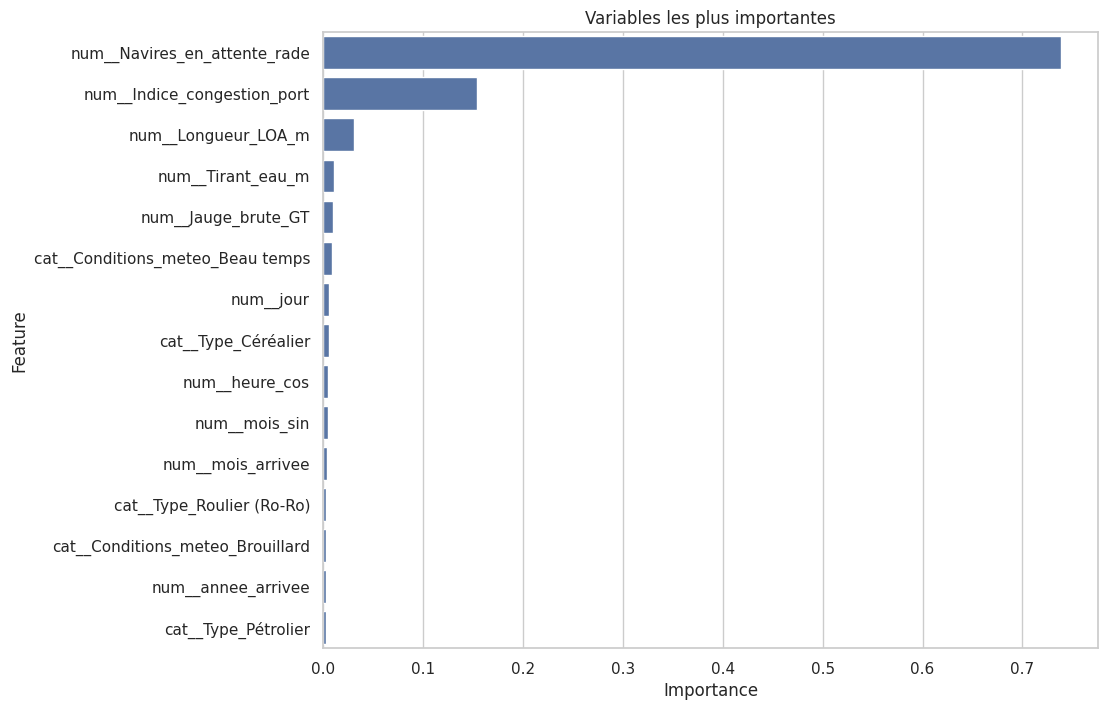

In [ ]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    y="Feature",
    x="Importance"
)

plt.title(
    "Variables les plus importantes"
)

plt.show()

In [ ]:
# ENTRAÎNEMENT FINAL

X_train_final = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

print(
    "Taille du dataset final d'entraînement :",
    X_train_final.shape
)

Taille du dataset final d'entraînement : (548, 18)


In [ ]:
final_model = best_model

final_model.fit(
    X_train_final,
    y_train_final
)

print("Modèle final entraîné.")

Modèle final entraîné.


In [ ]:
# SAUVEGARDE DU MODÈLE

joblib.dump(
    final_model,
    "modele_prediction_temps_rade.pkl"
)

print(
    "Modèle sauvegardé sous : "
    "modele_prediction_temps_rade.pkl"
)

Modèle sauvegardé sous : modele_prediction_temps_rade.pkl


In [ ]:
from google.colab import files

files.download(
    "modele_prediction_temps_rade.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# PRÉDICTION D'UN NOUVEAU NAVIRE

def predire_temps_attente(
    modele,
    type_navire,
    jauge_gt,
    longueur,
    tirant_eau,
    navires_attente,
    congestion,
    meteo,
    date_arrivee
):

    date_arrivee = pd.to_datetime(
        date_arrivee
    )

    heure = date_arrivee.hour
    jour = date_arrivee.day
    mois = date_arrivee.month
    annee = date_arrivee.year
    jour_semaine = date_arrivee.dayofweek

    weekend = int(
        jour_semaine >= 5
    )

    trimestre = (
        (mois - 1) // 3 + 1
    )

    heure_sin = np.sin(
        2 * np.pi * heure / 24
    )

    heure_cos = np.cos(
        2 * np.pi * heure / 24
    )

    mois_sin = np.sin(
        2 * np.pi * mois / 12
    )

    mois_cos = np.cos(
        2 * np.pi * mois / 12
    )

    nouvelle_observation = pd.DataFrame([{

        "Type": type_navire,

        "Jauge_brute_GT": jauge_gt,

        "Longueur_LOA_m": longueur,

        "Tirant_eau_m": tirant_eau,

        "Navires_en_attente_rade":
            navires_attente,

        "Indice_congestion_port":
            congestion,

        "Conditions_meteo":
            meteo,

        "heure_arrivee":
            heure,

        "jour":
            jour,

        "mois_arrivee":
            mois,

        "annee_arrivee":
            annee,

        "jour_semaine_num":
            jour_semaine,

        "weekend":
            weekend,

        "trimestre":
            trimestre,

        "heure_sin":
            heure_sin,

        "heure_cos":
            heure_cos,

        "mois_sin":
            mois_sin,

        "mois_cos":
            mois_cos
    }])

    prediction = modele.predict(
        nouvelle_observation
    )[0]

    return prediction

In [ ]:
# EXEMPLE

prediction = predire_temps_attente(

    modele=final_model,

    type_navire="Porte-conteneurs",

    jauge_gt=50000,

    longueur=250,

    tirant_eau=13,

    navires_attente=10,

    congestion=0.65,

    meteo="Beau temps",

    date_arrivee="2026-08-26 10:30"
)

print(
    f"Temps d'attente prédit : "
    f"{prediction:.2f} heures"
)

print(
    f"Soit environ : "
    f"{prediction / 24:.2f} jours"
)

Temps d'attente prédit : 61.51 heures
Soit environ : 2.56 jours
